# %% [markdown]
# # 06 — MGA (Mars): Earth → Mars → Jupiter
# 
# Mars gravity assist on the way to Jupiter. Mars sits at 1.52 AU, roughly 
# on the route to Jupiter, so a flyby there could provide a useful kick.
# However, Mars has only 0.107 Earth masses — much weaker than Venus (0.815)
# or Earth (1.0) — so the turn angle per flyby is limited.
#
# This notebook quantitatively tests whether a Mars flyby is competitive
# with Venus/Earth-based sequences, allowing us to scientifically rule it
# in or out.
#
# **Sequence:** Earth → Mars → Jupiter (2 legs, 1 flyby)
# **Search space:** 10 dimensions (same as ΔV-EGA)
#
# **IMPORTANT**: pykep mga_1dsm stores velocities in **m/s** internally.

In [3]:
# %% Cell 1 — Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import pykep as pk
import pygmo as pg
from pykep import propagate_lagrangian, AU

print(f"pykep version: {pk.__version__}")
print(f"pygmo version: {pg.__version__}")

pykep version: {'major': 2, 'minor': 6}
pygmo version: 2.19.7


In [4]:
# %% Cell 2 — Define the MGA-1DSM problem
#
# Sequence: Earth → Mars → Jupiter
# Leg 1 (E→M): ~0.5–2.0 yr (Earth to Mars transfer)
# Leg 2 (M→J): ~1.0–6.0 yr (Mars to Jupiter transfer)

seq = [
    pk.planet.jpl_lp('earth'),    # departure
    pk.planet.jpl_lp('mars'),     # flyby
    pk.planet.jpl_lp('jupiter'),  # arrival
]

udp = pk.trajopt.mga_1dsm(
    seq=seq,
    t0=[pk.epoch_from_string('2030-01-01 00:00:00'),
        pk.epoch_from_string('2038-01-01 00:00:00')],
    tof=[[150, 700],      # Leg 1: E→M (days) — Hohmann ~259d, but allow wider range
         [300, 2500]],    # Leg 2: M→J (days) — longer than E→J since starting further
    vinf=[0.5, 8.0],      # departure V∞ bounds (km/s) — wider since Mars may need more
    add_vinf_dep=True,
    add_vinf_arr=True,
    tof_encoding='direct',
    multi_objective=False,
)

prob = pg.problem(udp)
print(prob)

Problem name: MGA_1DSM Trajectory
	C++ class name: pybind11::object

	Global dimension:			10
	Integer dimension:			0
	Fitness dimension:			1
	Number of objectives:			1
	Equality constraints dimension:		0
	Inequality constraints dimension:	0
	Lower bounds: [10958, 0, 0, 500, 0.1, ... ]
	Upper bounds: [13880, 1, 1, 8000, 0.9, ... ]
	Has batch fitness evaluation: false

	Has gradient: false
	User implemented gradient sparsity: false
	Has hessians: false
	User implemented hessians sparsity: false

	Fitness evaluations: 0

	Thread safety: none

Extra info:

	 Sequence: ['earth', 'mars', 'jupiter']
	 Add launcher vinf to the objective?: True
	 Add final vinf to the objective?: True


In [5]:
# %% Cell 3 — Multi-restart global search
#
# 10-D search space (same as ΔV-EGA). Should converge more easily.

# --- Phase 1: Broad search ---
print("Phase 1: Broad search ...")

algo_phase1 = pg.algorithm(pg.sade(gen=200))
algo_phase1.set_verbosity(0)

archi = pg.archipelago(algo=algo_phase1, prob=prob, n=64, pop_size=25)

for i in range(6):
    archi.evolve()
    archi.wait()
    best_so_far = min(isl.get_population().champion_f[0] for isl in archi)
    print(f"  Round {i+1}/6: best = {best_so_far/1000:.4f} km/s")

# Collect champions
phase1_f = [isl.get_population().champion_f[0] for isl in archi]
phase1_x = [isl.get_population().champion_x for isl in archi]

ranked = sorted(zip(phase1_f, phase1_x), key=lambda pair: pair[0])
top_seeds = ranked[:20]
print(f"\nPhase 1 complete. Top 5 solutions (km/s):")
for i, (f, x) in enumerate(top_seeds[:5]):
    print(f"  #{i+1}: {f/1000:.4f} km/s")

# --- Phase 2: Refine top seeds ---
print("\nPhase 2: Refining top 20 solutions ...")

algo_phase2 = pg.algorithm(pg.sade(gen=500))
algo_phase2.set_verbosity(0)

best_overall_f = float('inf')
best_overall_x = None

for i, (f_seed, x_seed) in enumerate(top_seeds):
    pop = pg.population(prob, size=25)
    pop.set_x(0, x_seed)
    pop = algo_phase2.evolve(pop)
    
    if pop.champion_f[0] < best_overall_f:
        best_overall_f = pop.champion_f[0]
        best_overall_x = pop.champion_x.copy()
    
    if (i + 1) % 5 == 0:
        print(f"  Refined {i+1}/20 seeds, best so far: {best_overall_f/1000:.4f} km/s")

# --- Phase 3: Local polish ---
print("\nPhase 3: Local refinement with Compass Search ...")

algo_local = pg.algorithm(pg.compass_search(max_fevals=50000, start_range=0.01, stop_range=1e-6))
algo_local.set_verbosity(0)

pop_final = pg.population(prob, size=1)
pop_final.set_x(0, best_overall_x)
pop_final = algo_local.evolve(pop_final)

best_f = pop_final.champion_f[0]
best_x = pop_final.champion_x.copy()

print(f"\nFinal best ΔV: {best_f/1000:.4f} km/s")

Phase 1: Broad search ...
  Round 1/6: best = 14.1037 km/s
  Round 2/6: best = 13.1317 km/s
  Round 3/6: best = 12.9036 km/s
  Round 4/6: best = 12.8296 km/s
  Round 5/6: best = 12.6857 km/s
  Round 6/6: best = 12.5227 km/s

Phase 1 complete. Top 5 solutions (km/s):
  #1: 12.5227 km/s
  #2: 12.5984 km/s
  #3: 12.6048 km/s
  #4: 12.6151 km/s
  #5: 12.6236 km/s

Phase 2: Refining top 20 solutions ...
  Refined 5/20 seeds, best so far: 12.4743 km/s
  Refined 10/20 seeds, best so far: 12.4743 km/s
  Refined 15/20 seeds, best so far: 12.4743 km/s
  Refined 20/20 seeds, best so far: 12.4743 km/s

Phase 3: Local refinement with Compass Search ...

Final best ΔV: 12.3033 km/s


In [6]:
# %% Cell 4 — Display best solution
print("=" * 60)
print("  MGA (Mars) — BEST SOLUTION")
print("=" * 60)
udp.pretty(best_x)
print("=" * 60)
print(f"\n  Objective (total ΔV): {best_f/1000:.4f} km/s")

  MGA (Mars) — BEST SOLUTION
First Leg: earth to mars
Departure: 2033-Apr-19 11:02:12.347373 (12162.459865131628 mjd2000) 
Duration: 687.7987234253613days
VINF: 0.5 km/sec
DSM after 150.4977879141373 days
DSM magnitude: 4446.503278808565m/s

leg no. 2: mars to jupiter
Duration: 1150.2056531233777days
Fly-by epoch: 2035-Mar-08 06:12:22.051324 (12850.25858855699 mjd2000) 
Fly-by radius: 1.1 planetary radii
DSM after 115.02056531233778 days
DSM magnitude: 2725.33875319098m/s

Arrival at jupiter
Arrival epoch: 2038-May-01 11:08:30.481184 (14000.464241680367 mjd2000) 
Arrival Vinf: 4631.442392961254m/s
Total mission time: 5.032181729086212 years (1838.004376548739 days)

  Objective (total ΔV): 12.3033 km/s


In [7]:
# %% Cell 5 — Extract key values for trade study
#
# Decision vector for mga_1dsm (direct encoding, 2 legs):
#   [t0, u, v, Vinf, eta1, T1, beta2, rp2/rV2, eta2, T2]

t0_mjd2000 = best_x[0]
vinf_dep_ms = best_x[3]
vinf_dep_kms = vinf_dep_ms / 1000.0
T1 = best_x[5]    # E→M (days)
T2 = best_x[9]    # M→J (days)
etas = [best_x[4], best_x[8]]

launch_epoch  = pk.epoch(t0_mjd2000, 'mjd2000')
mars_epoch    = pk.epoch(t0_mjd2000 + T1, 'mjd2000')
jupiter_epoch = pk.epoch(t0_mjd2000 + T1 + T2, 'mjd2000')

c3_dep = vinf_dep_kms ** 2
total_tof = T1 + T2

print("=" * 60)
print("  MGA (Mars) — KEY PARAMETERS")
print("=" * 60)
print(f"  Launch:          {launch_epoch}")
print(f"  Mars flyby:      {mars_epoch}")
print(f"  Jupiter arrival: {jupiter_epoch}")
print(f"  Leg 1 TOF (E→M): {T1:.1f} days ({T1/365.25:.2f} yr)")
print(f"  Leg 2 TOF (M→J): {T2:.1f} days ({T2/365.25:.2f} yr)")
print(f"  Total TOF:        {total_tof:.1f} days ({total_tof/365.25:.2f} yr)")
print(f"  C3 (departure):   {c3_dep:.2f} km²/s²")
print(f"  V∞ (departure):   {vinf_dep_kms:.3f} km/s")
print(f"  Total ΔV (obj):   {best_f/1000:.4f} km/s")
print("=" * 60)

# Flyby altitude
mars_radius_km = 3396.0
mars_safe_r_km = seq[1].safe_radius / 1000.0
mars_rp_ratio = best_x[7]
mars_flyby_alt = mars_rp_ratio * mars_safe_r_km - mars_radius_km

print(f"\n  Mars flyby altitude: ~{mars_flyby_alt:.0f} km (rp ratio: {mars_rp_ratio:.2f})")

# Sanity checks
print("\nSanity checks:")
if c3_dep > 50:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — very high")
elif c3_dep > 30:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — high")
else:
    print(f"  ✓ C3 = {c3_dep:.1f} km²/s² — reasonable")

total_dsm = best_f/1000 - vinf_dep_kms
print(f"  Total non-departure ΔV (DSMs + arrival V∞): ~{total_dsm:.2f} km/s")
print(f"\n  Note: Mars mass = 0.107 M_Earth → limited flyby turn angle")


  MGA (Mars) — KEY PARAMETERS
  Launch:          2033-Apr-19 11:02:12.347373
  Mars flyby:      2035-Mar-08 06:12:22.051324
  Jupiter arrival: 2038-May-01 11:08:30.481184
  Leg 1 TOF (E→M): 687.8 days (1.88 yr)
  Leg 2 TOF (M→J): 1150.2 days (3.15 yr)
  Total TOF:        1838.0 days (5.03 yr)
  C3 (departure):   0.25 km²/s²
  V∞ (departure):   0.500 km/s
  Total ΔV (obj):   12.3033 km/s

  Mars flyby altitude: ~714 km (rp ratio: 1.10)

Sanity checks:
  ✓ C3 = 0.2 km²/s² — reasonable
  Total non-departure ΔV (DSMs + arrival V∞): ~11.80 km/s

  Note: Mars mass = 0.107 M_Earth → limited flyby turn angle


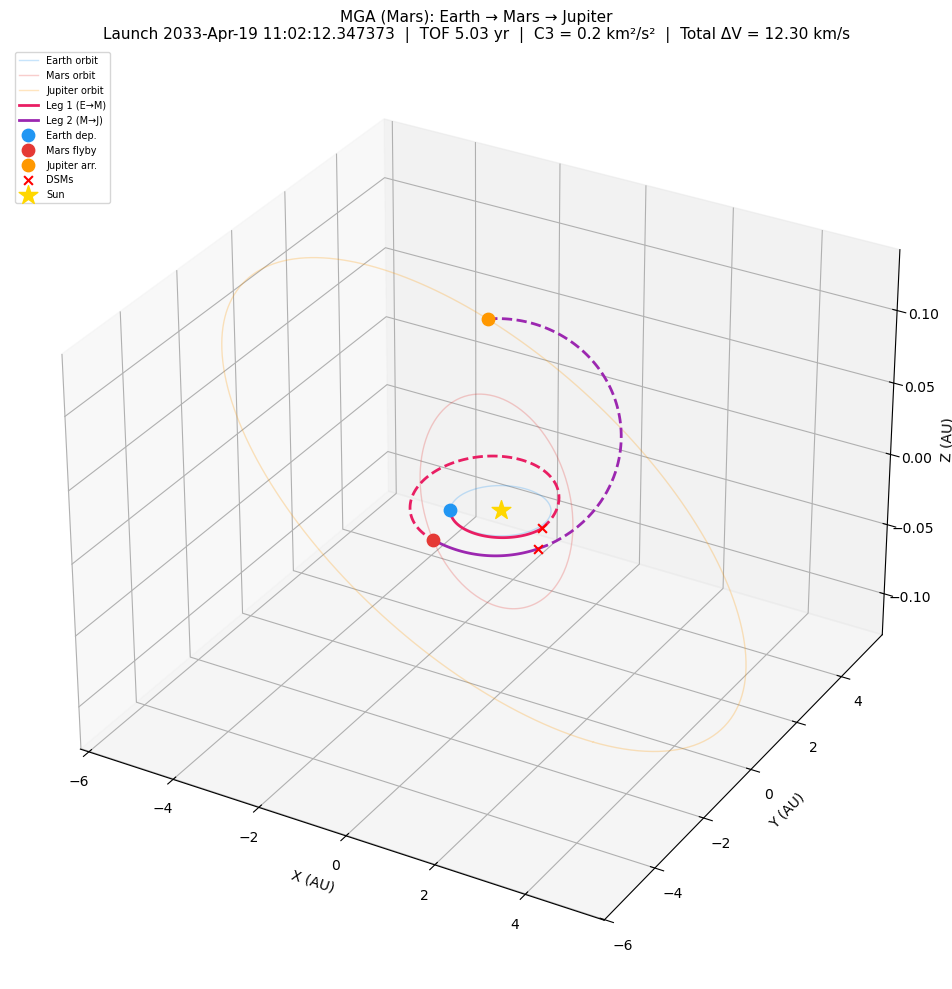

Saved: output/06_trajectory_mga.png
Saved: output/06_trajectory_mga.gif


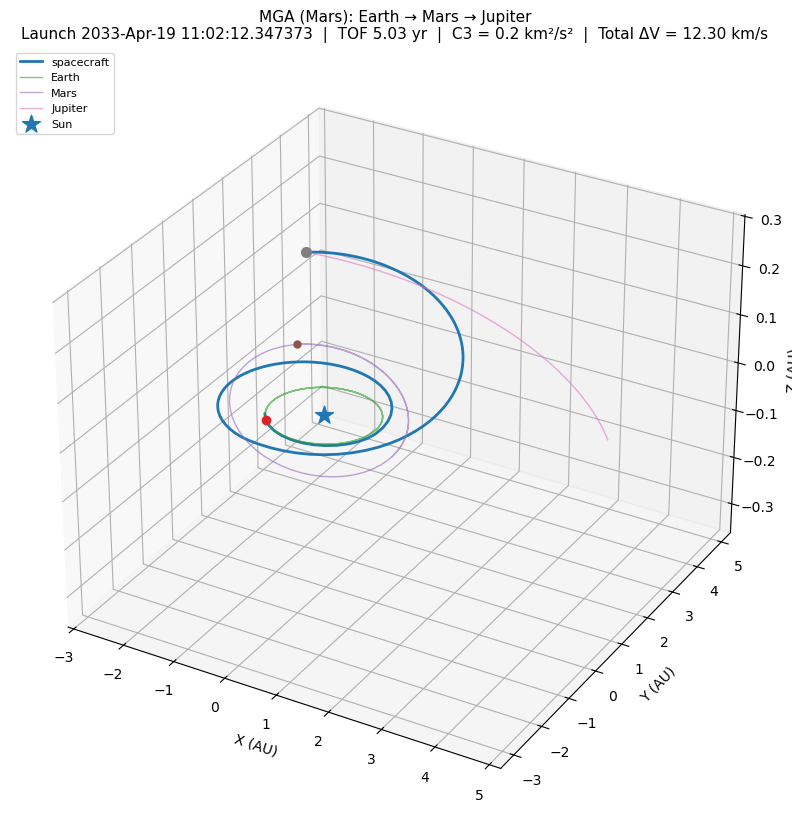

In [8]:
# %% Cell 6 — Trajectory plot (static PNG)
t0_mjd = t0_mjd2000
T_legs = [T1, T2]

# --- Departure state ---
r_dep, v_dep_planet = seq[0].eph(pk.epoch(t0_mjd, 'mjd2000'))
theta = 2 * np.pi * best_x[1]
phi = np.arccos(2 * best_x[2] - 1) - np.pi / 2
Vinfx = vinf_dep_ms * np.cos(phi) * np.cos(theta)
Vinfy = vinf_dep_ms * np.cos(phi) * np.sin(theta)
Vinfz = vinf_dep_ms * np.sin(phi)
v0 = [v_dep_planet[0] + Vinfx, v_dep_planet[1] + Vinfy, v_dep_planet[2] + Vinfz]

# --- Build leg data ---
enc_epochs = [t0_mjd]
for t_leg in T_legs:
    enc_epochs.append(enc_epochs[-1] + t_leg)

r_enc = []
v_enc_planet = []
for i, ep_mjd in enumerate(enc_epochs):
    idx = min(i, len(seq) - 1)
    r_tmp, v_tmp = seq[idx].eph(pk.epoch(ep_mjd, 'mjd2000'))
    r_enc.append(r_tmp)
    v_enc_planet.append(v_tmp)

legs_data = []
r_start = r_dep
v_start = v0

for leg_idx in range(len(T_legs)):
    eta = etas[leg_idx]
    dt_leg = T_legs[leg_idx] * 86400.0
    dt_pre = eta * dt_leg
    dt_post = (1 - eta) * dt_leg
    
    r_dsm, v_dsm = propagate_lagrangian(r_start, v_start, dt_pre, pk.MU_SUN)
    r_next = r_enc[leg_idx + 1]
    lamb = pk.lambert_problem(r_dsm, r_next, dt_post, pk.MU_SUN)
    v_post_dsm = lamb.get_v1()[0]
    v_arr = lamb.get_v2()[0]
    
    legs_data.append({
        'r_start': r_start, 'v_start': v_start,
        'dt_pre': dt_pre, 'r_dsm': r_dsm,
        'v_post_dsm': v_post_dsm, 'dt_post': dt_post,
        'r_end': r_next, 'v_arr': v_arr,
    })
    
    if leg_idx < len(T_legs) - 1:
        dt_next_leg = T_legs[leg_idx + 1] * 86400.0
        r_next_next = r_enc[leg_idx + 2]
        lamb_next = pk.lambert_problem(r_next, r_next_next, dt_next_leg, pk.MU_SUN)
        r_start = r_next
        v_start = lamb_next.get_v1()[0]

# --- Static plot ---
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

n_pts = 100

# Planet orbits
for planet, color, label in [(seq[0], '#2196F3', 'Earth orbit'),
                              (seq[1], '#E53935', 'Mars orbit'),
                              (seq[2], '#FF9800', 'Jupiter orbit')]:
    period = planet.compute_period(pk.epoch(t0_mjd, 'mjd2000'))
    t_orb = np.linspace(0, period, 200)
    xo, yo, zo = [], [], []
    for dt in t_orb:
        r, _ = planet.eph(pk.epoch(t0_mjd + dt/86400.0, 'mjd2000'))
        xo.append(r[0]/AU); yo.append(r[1]/AU); zo.append(r[2]/AU)
    ax.plot(xo, yo, zo, color=color, alpha=0.25, linewidth=1, label=label)

# Trajectory legs
leg_colors = ['#E91E63', '#9C27B0']
leg_labels = ['Leg 1 (E→M)', 'Leg 2 (M→J)']

for i, (ld, col, lab) in enumerate(zip(legs_data, leg_colors, leg_labels)):
    arc_x, arc_y, arc_z = [], [], []
    for frac in np.linspace(0, 1, n_pts):
        r, _ = propagate_lagrangian(ld['r_start'], ld['v_start'], frac * ld['dt_pre'], pk.MU_SUN)
        arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
    ax.plot(arc_x, arc_y, arc_z, color=col, linewidth=2, label=lab)
    
    arc_x, arc_y, arc_z = [], [], []
    for frac in np.linspace(0, 1, n_pts):
        r, _ = propagate_lagrangian(ld['r_dsm'], ld['v_post_dsm'], frac * ld['dt_post'], pk.MU_SUN)
        arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
    ax.plot(arc_x, arc_y, arc_z, color=col, linewidth=2, linestyle='--')
    
    ax.scatter([ld['r_dsm'][0]/AU], [ld['r_dsm'][1]/AU], [ld['r_dsm'][2]/AU],
               s=40, c='red', marker='x', zorder=5)

# Encounter markers
enc_labels = ['Earth dep.', 'Mars flyby', 'Jupiter arr.']
enc_colors = ['#2196F3', '#E53935', '#FF9800']
for r_e, lab, col in zip(r_enc, enc_labels, enc_colors):
    ax.scatter([r_e[0]/AU], [r_e[1]/AU], [r_e[2]/AU],
               s=80, c=col, marker='o', label=lab, zorder=5)

ax.scatter([], [], [], s=40, c='red', marker='x', label='DSMs')
ax.scatter([0], [0], [0], s=200, c='gold', marker='*', label='Sun', zorder=10)

ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')
ax.legend(fontsize=7, loc='upper left')
ax.set_title(f'MGA (Mars): Earth → Mars → Jupiter\n'
             f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
             f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
             fontsize=11)

plt.tight_layout()
plt.savefig('output/06_trajectory_mga.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/06_trajectory_mga.png")

# %% Cell 6b — Animated GIF
from matplotlib.animation import FuncAnimation, PillowWriter

fps = 12
days_per_frame = 12
max_frames = 450

seg_bounds = [0.0]
for ld in legs_data:
    seg_bounds.append(seg_bounds[-1] + ld['dt_pre'])
    seg_bounds.append(seg_bounds[-1] + ld['dt_post'])

t_total = seg_bounds[-1]
seconds_per_frame = days_per_frame * 86400.0
n_frames = int(min(max_frames, np.ceil(t_total / seconds_per_frame))) + 1
t_grid = np.linspace(0.0, t_total, n_frames)

xs_sc = np.zeros(n_frames); ys_sc = np.zeros(n_frames); zs_sc = np.zeros(n_frames)
xe = np.zeros(n_frames); ye = np.zeros(n_frames); ze = np.zeros(n_frames)
xm = np.zeros(n_frames); ym = np.zeros(n_frames); zm = np.zeros(n_frames)
xjp = np.zeros(n_frames); yjp = np.zeros(n_frames); zjp = np.zeros(n_frames)

for k, t in enumerate(t_grid):
    for seg_idx in range(len(seg_bounds) - 1):
        if t <= seg_bounds[seg_idx + 1] or seg_idx == len(seg_bounds) - 2:
            break
    
    leg_idx = seg_idx // 2
    is_post_dsm = seg_idx % 2 == 1
    dt_local = t - seg_bounds[seg_idx]
    
    ld = legs_data[leg_idx]
    if is_post_dsm:
        r, _ = propagate_lagrangian(ld['r_dsm'], ld['v_post_dsm'], dt_local, pk.MU_SUN)
    else:
        r, _ = propagate_lagrangian(ld['r_start'], ld['v_start'], dt_local, pk.MU_SUN)
    
    xs_sc[k] = r[0]/AU; ys_sc[k] = r[1]/AU; zs_sc[k] = r[2]/AU

    abs_mjd = t0_mjd + t / 86400.0
    ep = pk.epoch(abs_mjd, 'mjd2000')
    re, _ = seq[0].eph(ep); rm, _ = seq[1].eph(ep); rj, _ = seq[2].eph(ep)
    xe[k] = re[0]/AU; ye[k] = re[1]/AU; ze[k] = re[2]/AU
    xm[k] = rm[0]/AU; ym[k] = rm[1]/AU; zm[k] = rm[2]/AU
    xjp[k] = rj[0]/AU; yjp[k] = rj[1]/AU; zjp[k] = rj[2]/AU

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

(sc_line,) = ax.plot([], [], [], linewidth=2, label='spacecraft')
(sc_dot,)  = ax.plot([], [], [], marker='o', markersize=5, linestyle='')
(tr_e,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Earth')
(pt_e,) = ax.plot([], [], [], marker='o', markersize=6, linestyle='')
(tr_m,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Mars')
(pt_m,) = ax.plot([], [], [], marker='o', markersize=5, linestyle='')
(tr_j,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Jupiter')
(pt_j,) = ax.plot([], [], [], marker='o', markersize=7, linestyle='')

ax.scatter([0], [0], [0], s=180, marker='*', label='Sun', zorder=10)
ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title(f'MGA (Mars): Earth → Mars → Jupiter\n'
             f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
             f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
             fontsize=11)

pad = 0.25
allx = np.concatenate([xs_sc, xe, xm, xjp])
ally = np.concatenate([ys_sc, ye, ym, yjp])
allz = np.concatenate([zs_sc, ze, zm, zjp])
ax.set_xlim(allx.min()-pad, allx.max()+pad)
ax.set_ylim(ally.min()-pad, ally.max()+pad)
ax.set_zlim(allz.min()-pad, allz.max()+pad)

trail_len = 80

def init():
    for obj in [sc_line, sc_dot, tr_e, pt_e, tr_m, pt_m, tr_j, pt_j]:
        obj.set_data([], [])
        obj.set_3d_properties([])
    return sc_line, sc_dot, tr_e, pt_e, tr_m, pt_m, tr_j, pt_j

def update(i):
    sc_line.set_data(xs_sc[:i+1], ys_sc[:i+1])
    sc_line.set_3d_properties(zs_sc[:i+1])
    sc_dot.set_data([xs_sc[i]], [ys_sc[i]])
    sc_dot.set_3d_properties([zs_sc[i]])
    j0 = max(0, i - trail_len)
    tr_e.set_data(xe[j0:i+1], ye[j0:i+1]); tr_e.set_3d_properties(ze[j0:i+1])
    pt_e.set_data([xe[i]], [ye[i]]); pt_e.set_3d_properties([ze[i]])
    tr_m.set_data(xm[j0:i+1], ym[j0:i+1]); tr_m.set_3d_properties(zm[j0:i+1])
    pt_m.set_data([xm[i]], [ym[i]]); pt_m.set_3d_properties([zm[i]])
    tr_j.set_data(xjp[j0:i+1], yjp[j0:i+1]); tr_j.set_3d_properties(zjp[j0:i+1])
    pt_j.set_data([xjp[i]], [yjp[i]]); pt_j.set_3d_properties([zjp[i]])
    return sc_line, sc_dot, tr_e, pt_e, tr_m, pt_m, tr_j, pt_j

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init,
                     interval=1000/fps, blit=True)
anim.save('output/06_trajectory_mga.gif', writer=PillowWriter(fps=fps))
print("Saved: output/06_trajectory_mga.gif")
plt.show()

In [9]:
# %% Cell 7 — Convergence diagnostics
print("Solution vector breakdown (2-leg, 10 variables):")
print(f"  t0 (mjd2000):      {best_x[0]:.2f} → {launch_epoch}")
print(f"  u (V∞ dir):         {best_x[1]:.4f}")
print(f"  v (V∞ dir):         {best_x[2]:.4f}")
print(f"  V∞ dep:             {best_x[3]:.1f} m/s = {best_x[3]/1000:.3f} km/s")
print(f"  η1 (DSM1):          {best_x[4]:.4f}")
print(f"  T1 (E→M days):      {best_x[5]:.1f}")
print(f"  β2 (Mars fb):       {best_x[6]:.4f}")
print(f"  rp2/rV2 (Mars):     {best_x[7]:.4f}")
print(f"  η2 (DSM2):          {best_x[8]:.4f}")
print(f"  T2 (M→J days):      {best_x[9]:.1f}")

print("\nBound checks:")
print(f"  T1: 150 ≤ {best_x[5]:.0f} ≤ 700    {'⚠ AT BOUND' if best_x[5] < 151 or best_x[5] > 699 else '✓'}")
print(f"  T2: 300 ≤ {best_x[9]:.0f} ≤ 2500   {'⚠ AT BOUND' if best_x[9] < 301 or best_x[9] > 2499 else '✓'}")
vinf_kms = best_x[3] / 1000
print(f"  V∞: 0.5 ≤ {vinf_kms:.2f} ≤ 8.0 km/s  {'⚠ AT BOUND' if vinf_kms < 0.51 or vinf_kms > 7.99 else '✓'}")


Solution vector breakdown (2-leg, 10 variables):
  t0 (mjd2000):      12162.46 → 2033-Apr-19 11:02:12.347373
  u (V∞ dir):         0.8312
  v (V∞ dir):         0.5169
  V∞ dep:             500.0 m/s = 0.500 km/s
  η1 (DSM1):          0.2188
  T1 (E→M days):      687.8
  β2 (Mars fb):       -1.5848
  rp2/rV2 (Mars):     1.1000
  η2 (DSM2):          0.1000
  T2 (M→J days):      1150.2

Bound checks:
  T1: 150 ≤ 688 ≤ 700    ✓
  T2: 300 ≤ 1150 ≤ 2500   ✓
  V∞: 0.5 ≤ 0.50 ≤ 8.0 km/s  ⚠ AT BOUND
